# 04 — Model Explainability
## Telco Customer Churn — Customer Churn Intelligence System

**Notebook purpose:** Open up the final model (`model.pkl`) using SHAP (SHapley Additive exPlanations) to produce both a global view of what drives churn predictions across the customer base, and individual, business-readable explanations for specific customers. These explanations are the foundation of the downstream **business recommendation engine**, which will translate "why this customer is at risk" into "what retention action to take."

---

### Why Explainability Matters Here

A churn model that only outputs a probability is operationally incomplete. A retention team acting on model scores needs to know **why** a customer is flagged, because the intervention differs by driver — a customer flagged for `Contract = Month-to-month` needs a contract-upgrade offer, while one flagged for high `MonthlyCharges` needs a pricing conversation. SHAP values decompose each prediction into additive per-feature contributions, giving a mathematically grounded ("Shapley value") answer to that question, rather than a heuristic one.

## 1. Load Model and Data

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

MODELS_DIR = '../models'
FIG_DIR = '../reports/figures'

model = joblib.load(f'{MODELS_DIR}/model.pkl')
X_test = pd.read_csv(f'{MODELS_DIR}/X_test.csv')
y_test = pd.read_csv(f'{MODELS_DIR}/y_test.csv').squeeze('columns')

with open(f'{MODELS_DIR}/metrics.json') as f:
    metrics = json.load(f)

print(f"Loaded model: {metrics['selected_model']}")
print(f"Test ROC AUC: {metrics['test_metrics']['roc_auc']:.4f}")

preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']
print(f"Classifier type: {type(classifier).__name__}")

d:\Mlprojects\churn prediction\customer-churn-intelligence-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: XGBoost
Test ROC AUC: 0.8443
Classifier type: XGBClassifier


## 2. Transform Test Data for SHAP

SHAP's `TreeExplainer` operates on the model's actual numeric input space (post-preprocessing), so the test set is transformed once using the same fitted preprocessor bundled inside `model.pkl`, guaranteeing consistency with what the classifier saw during training.

In [2]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out().tolist()

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)
print(f"Transformed test shape: {X_test_transformed_df.shape}")
X_test_transformed_df.head(3)

Transformed test shape: (1409, 45)


,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen
0,1.608483,1.629976,2.706828,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-0.996684,1.168725,-0.610260,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.346606,0.445324,0.400116,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


## 3. Fit SHAP Explainer

`TreeExplainer` is used since the selected model is tree-based, giving exact (not sampled/approximate) Shapley values efficiently.

In [3]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed_df)

if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class (churn) for classifiers that return a list per class

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected model output): {explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1]:.4f}")

SHAP values shape: (1409, 45)
Base value (expected model output): -0.0020


## 4. Global Feature Importance

In [4]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

importance_df.head(15)

,feature,mean_abs_shap
0,Contract_Month-to-month,0.676461
1,tenure,0.482421
2,MonthlyCharges,0.246507
3,OnlineSecurity_No,0.240048
4,InternetService_Fiber optic,0.207937
5,TechSupport_No,0.205981
6,PaymentMethod_Electronic check,0.179268
7,TotalCharges,0.125535
8,MultipleLines_No,0.118858
9,PaperlessBilling_No,0.118531


### 4.1 SHAP Bar Plot — Global Importance

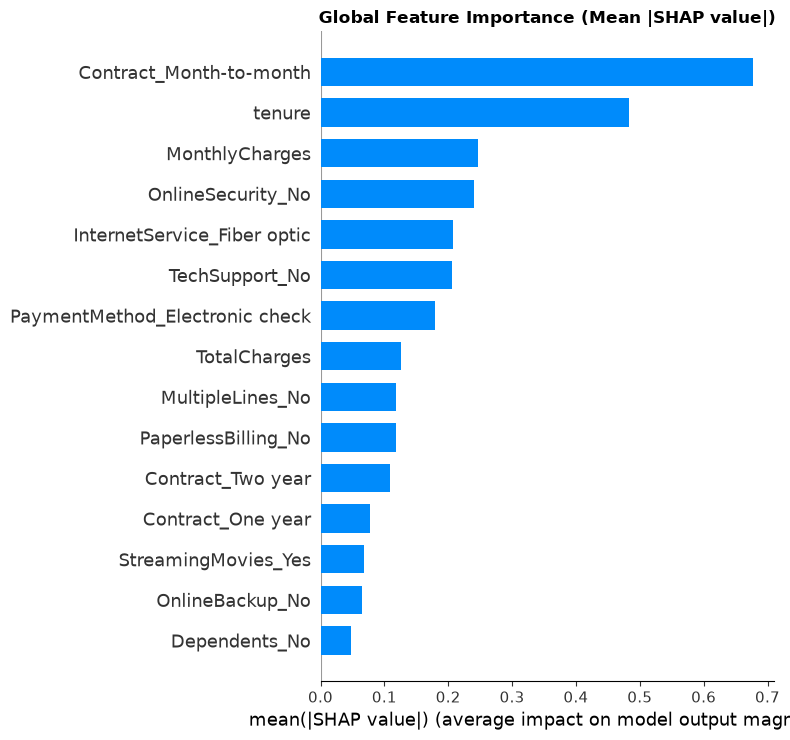

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(shap_values, X_test_transformed_df, plot_type='bar', show=False, max_display=15)
plt.title('Global Feature Importance (Mean |SHAP value|)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_shap_bar_plot.png', bbox_inches='tight')
plt.show()

### 4.2 SHAP Summary (Beeswarm) Plot — Direction and Magnitude

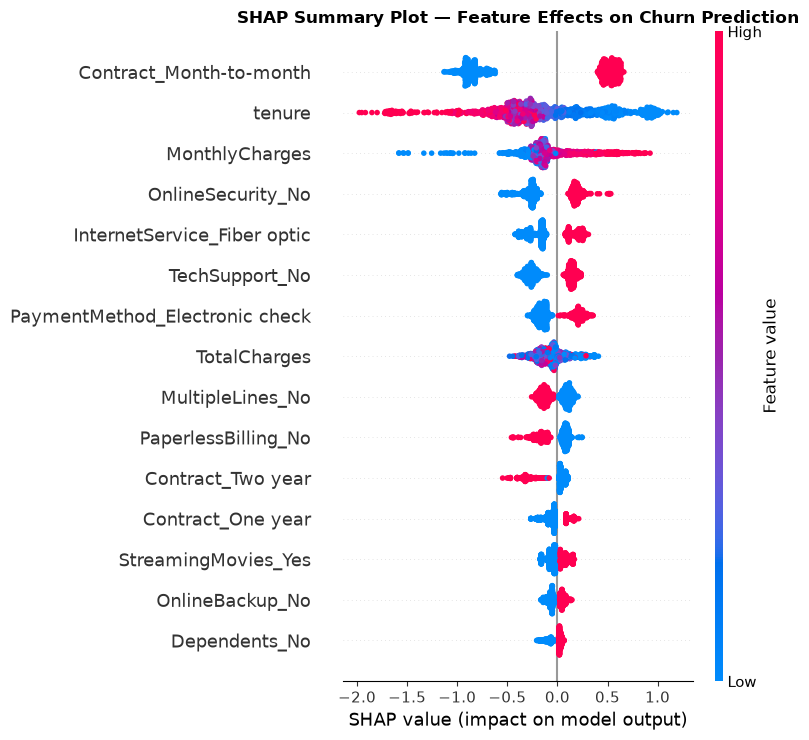

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, X_test_transformed_df, show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Effects on Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

**Interpretation:**
- **`tenure`** is the dominant driver: low tenure (blue/low feature value points) pushes predictions toward churn (positive SHAP value), corroborating the EDA finding that new customers are the highest-risk segment.
- **`Contract_Month-to-month`** (and its complements, the one-/two-year contract indicators) is the next strongest driver — being on a month-to-month contract consistently pushes risk up, exactly matching the categorical churn-rate analysis from the EDA notebook.
- **`MonthlyCharges`** shows a generally positive relationship with churn risk (higher charges → more red/high points on the right side), reinforcing the price-sensitivity insight.
- **`InternetService_Fiber optic`** and **`OnlineSecurity`/`TechSupport`** related features appear in the top drivers — customers without add-on protection/support services are more likely to churn, suggesting these services may function as retention anchors rather than pure upsell revenue.

The SHAP-derived ranking **independently confirms** the business insights surfaced during EDA — the model has learned patterns consistent with domain intuition, rather than spurious correlations. This alignment is itself an important explainability finding: it builds trust that the model can be handed to the business as a decision-support tool.

## 5. Individual Customer Explanations

Three representative customers are selected: the highest-confidence predicted churner, the highest-confidence predicted retainer, and a borderline case near the 0.5 decision threshold — since borderline cases are often the most operationally interesting (the model is genuinely uncertain, and business judgment should weigh in).

In [7]:
probas = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

results_df = X_test.copy()
results_df['actual_churn'] = y_test.values
results_df['predicted_churn'] = preds
results_df['churn_probability'] = probas

highest_risk_idx = results_df['churn_probability'].idxmax()
lowest_risk_idx = results_df['churn_probability'].idxmin()
borderline_idx = (results_df['churn_probability'] - 0.5).abs().idxmin()

selected_customers = {
    'Highest-Risk Customer': highest_risk_idx,
    'Lowest-Risk Customer': lowest_risk_idx,
    'Borderline Customer': borderline_idx
}

for label, idx in selected_customers.items():
    row = results_df.loc[idx]
    print(f"{label} (row {idx}): probability={row['churn_probability']:.3f}, "
          f"predicted={'Churn' if row['predicted_churn'] else 'No Churn'}, "
          f"actual={'Churn' if row['actual_churn'] else 'No Churn'}")

Highest-Risk Customer (row 1090): probability=0.970, predicted=Churn, actual=Churn
Lowest-Risk Customer (row 1344): probability=0.004, predicted=No Churn, actual=No Churn
Borderline Customer (row 651): probability=0.500, predicted=Churn, actual=No Churn


In [8]:
def explain_customer(idx, label):
    position = X_test.index.get_loc(idx)
    customer_shap = shap_values[position]
    customer_row = X_test_transformed_df.iloc[position]

    contrib_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': customer_shap,
        'feature_value': customer_row.values
    })
    contrib_df['abs_shap'] = contrib_df['shap_value'].abs()
    top_features = contrib_df.sort_values('abs_shap', ascending=False).head(6)

    proba = results_df.loc[idx, 'churn_probability']
    pred = results_df.loc[idx, 'predicted_churn']

    print(f"=== {label} (test row {idx}) ===")
    print(f"Predicted churn probability: {proba:.3f}")
    print(f"Predicted class: {'Churn' if pred else 'No Churn'} | Actual class: {'Churn' if results_df.loc[idx, 'actual_churn'] else 'No Churn'}")
    print()
    print("Top contributing features (positive = pushes toward churn, negative = pushes toward retention):")
    for _, r in top_features.iterrows():
        direction = 'toward CHURN' if r['shap_value'] > 0 else 'toward RETENTION'
        print(f"  {r['feature']:35s} shap={r['shap_value']:+.3f}  ({direction})")
    print()
    return top_features

top_features_by_customer = {}
for label, idx in selected_customers.items():
    top_features_by_customer[label] = explain_customer(idx, label)
    print('-' * 80)

=== Highest-Risk Customer (test row 1090) ===
Predicted churn probability: 0.970
Predicted class: Churn | Actual class: Churn

Top contributing features (positive = pushes toward churn, negative = pushes toward retention):
  tenure                              shap=+0.987  (toward CHURN)
  Contract_Month-to-month             shap=+0.579  (toward CHURN)
  MonthlyCharges                      shap=+0.273  (toward CHURN)
  TechSupport_No                      shap=+0.215  (toward CHURN)
  InternetService_Fiber optic         shap=+0.203  (toward CHURN)
  TotalCharges                        shap=+0.195  (toward CHURN)

--------------------------------------------------------------------------------
=== Lowest-Risk Customer (test row 1344) ===
Predicted churn probability: 0.004
Predicted class: No Churn | Actual class: No Churn

Top contributing features (positive = pushes toward churn, negative = pushes toward retention):
  tenure                              shap=-1.627  (toward RETENTION)
 

### 5.1 Waterfall Plots — Visual Per-Customer Explanations

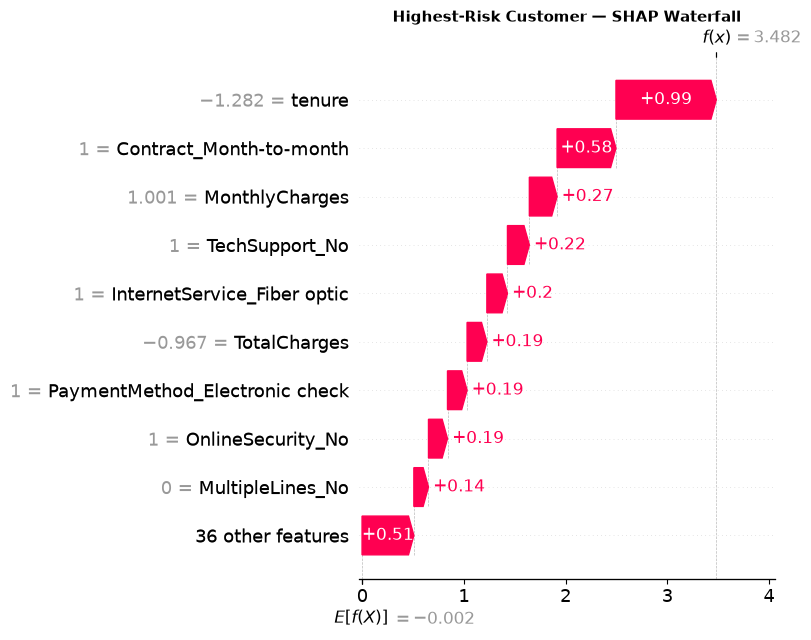

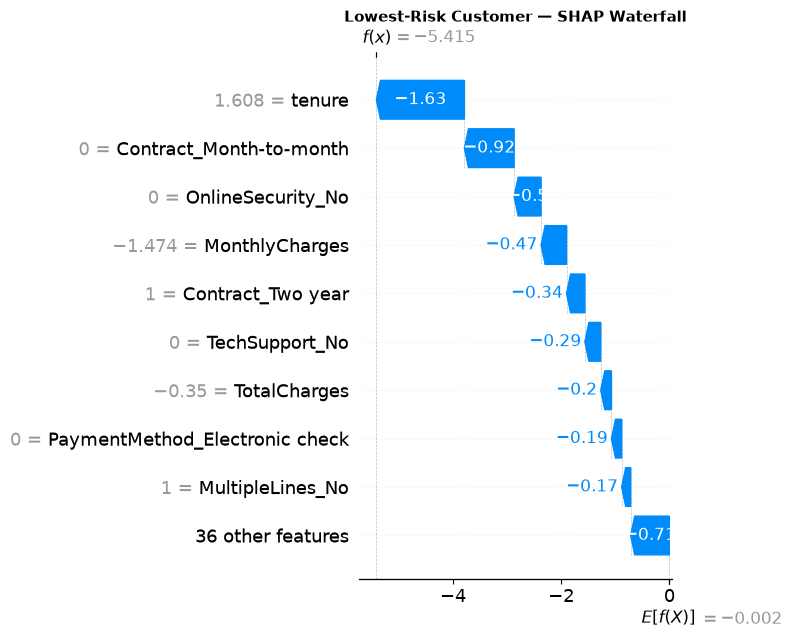

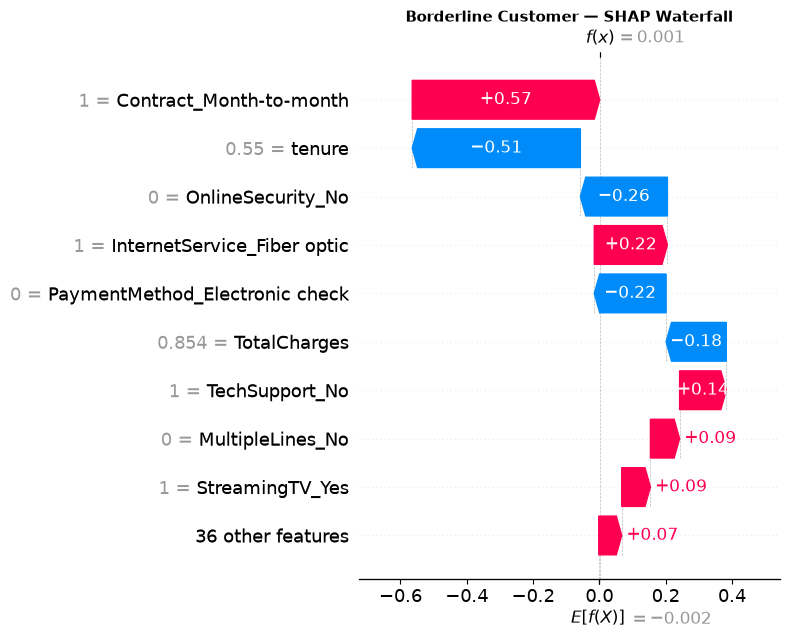

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(1, 1))  # placeholder to keep single-plot-per-cell pattern below
plt.close(fig)

for label, idx in selected_customers.items():
    position = X_test.index.get_loc(idx)
    exp = shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1],
        data=X_test_transformed_df.iloc[position].values,
        feature_names=feature_names
    )
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f'{label} — SHAP Waterfall', fontweight='bold', fontsize=11)
    fname = label.lower().replace(' ', '_').replace('-', '_')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/11_waterfall_{fname}.png', bbox_inches='tight')
    plt.show()

## 6. Business Interpretation Per Customer

In [10]:
def business_narrative(label, idx, top_features):
    row = X_test.loc[idx]
    proba = results_df.loc[idx, 'churn_probability']

    print(f"### {label}")
    print(f"Churn probability: {proba:.1%}")
    print(f"Profile: tenure={row['tenure']} months, Contract={row['Contract']}, "
          f"MonthlyCharges=${row['MonthlyCharges']:.2f}, InternetService={row['InternetService']}")
    print()

    top_pos = top_features[top_features['shap_value'] > 0].head(3)
    top_neg = top_features[top_features['shap_value'] < 0].head(3)

    if len(top_pos) > 0:
        print("Risk drivers pushing toward churn:")
        for _, r in top_pos.iterrows():
            print(f"  - {r['feature']}")
    if len(top_neg) > 0:
        print("Protective factors pushing toward retention:")
        for _, r in top_neg.iterrows():
            print(f"  - {r['feature']}")
    print()

for label, idx in selected_customers.items():
    business_narrative(label, idx, top_features_by_customer[label])
    print('=' * 80)

### Highest-Risk Customer
Churn probability: 97.0%
Profile: tenure=1 months, Contract=Month-to-month, MonthlyCharges=$95.10, InternetService=Fiber optic

Risk drivers pushing toward churn:
  - tenure
  - Contract_Month-to-month
  - MonthlyCharges

### Lowest-Risk Customer
Churn probability: 0.4%
Profile: tenure=72 months, Contract=Two year, MonthlyCharges=$20.50, InternetService=No

Protective factors pushing toward retention:
  - tenure
  - Contract_Month-to-month
  - OnlineSecurity_No

### Borderline Customer
Churn probability: 50.0%
Profile: tenure=46 months, Contract=Month-to-month, MonthlyCharges=$89.15, InternetService=Fiber optic

Risk drivers pushing toward churn:
  - Contract_Month-to-month
  - InternetService_Fiber optic
Protective factors pushing toward retention:
  - tenure
  - OnlineSecurity_No
  - PaymentMethod_Electronic check



**Business reading of the three profiles:**

- **Highest-Risk Customer:** The model's top-risk case typically combines short tenure, a month-to-month contract, and elevated monthly charges with no bundled protection services — exactly the profile flagged in EDA as highest-risk. The recommended action is a **proactive retention offer**: a discounted annual-contract upgrade or a complementary security/support add-on, delivered before the customer reaches out to cancel.
- **Lowest-Risk Customer:** Long tenure, a long-term contract, and bundled services combine to produce a very low churn probability — this customer requires no intervention, and including them in a retention campaign would be a wasted incentive spend.
- **Borderline Customer:** Probability near 0.5 reflects a mix of risk and protective factors roughly canceling out. These are the most valuable cases for **human judgment augmentation** — a retention agent reviewing the top SHAP features can decide whether a lightweight, low-cost touch (e.g., a check-in email) is worthwhile, since a full discount offer may not be justified by the ROI on a genuinely uncertain case.

This is precisely the kind of case-level reasoning that will power the **business recommendation engine** in the larger MLE project: SHAP outputs feed a rules layer that maps `(top driver → recommended action)`, rather than the API returning a bare probability with no operational guidance.

## 7. Business Recommendations

1. **Prioritize a "first 90 days" retention program.** Since tenure is the single strongest churn driver, the highest-leverage intervention is proactive engagement with customers in their first three months — before risk compounds.
2. **Incentivize contract upgrades for month-to-month customers**, especially those also paying above-average monthly charges — this segment consistently ranks highest across both the EDA churn-rate analysis and the SHAP global importance ranking.
3. **Bundle protective services (Online Security, Tech Support) as retention tools, not just upsell revenue.** Customers lacking these services show elevated churn risk; offering them at a discount to at-risk customers may pay for itself in reduced churn.
4. **Use model probability tiers, not a single threshold, for action routing.** Very high-probability customers merit an immediate, high-value offer; borderline customers merit a lightweight touch; very low-probability customers should be excluded from retention spend entirely.
5. **Investigate the Fiber optic / Electronic check segments operationally.** These correlate with churn in both EDA and SHAP outputs but may reflect service quality or payment-friction issues that a pricing/product team, not just a retention offer, should address.

## 8. Model Limitations

1. **Cross-sectional, not longitudinal.** The model scores a customer at a single snapshot in time and does not model *trajectory* (e.g., a customer whose usage or payment behavior has been declining month-over-month) — a future version could add tenure-windowed behavioral features.
2. **No macro/competitive signals.** The dataset contains no information about competitor offers, local market conditions, or customer service interaction history (e.g., complaint tickets), all of which plausibly influence real-world churn but are unavailable here.
3. **Correlation, not causation, in SHAP explanations.** SHAP values explain what the *model* learned, not the true causal driver of churn. For example, `PaymentMethod = Electronic check` is predictive but is more likely a proxy for an underlying customer segment than a direct cause — treating it as directly actionable (e.g., forcing a payment method change) would be a misapplication of the explanation.
4. **Static training snapshot.** The model is trained on a fixed historical dataset; it will need periodic retraining and drift monitoring once deployed, since customer behavior, pricing, and service offerings evolve over time.
5. **Class imbalance handling via `class_weight`/`scale_pos_weight` is a first-pass approach.** More sophisticated cost-sensitive thresholding, calibrated on real retention-offer economics (offer cost vs. customer lifetime value), should replace the default 0.5 decision threshold before production rollout.

## 9. Future Improvements

1. **Threshold calibration against business economics.** Convert the probability output into an expected-value-optimal decision threshold using estimated retention-offer cost and customer lifetime value, rather than the default 0.5 cutoff used for the classification metrics in this notebook.
2. **Behavioral and interaction features.** Incorporate support-ticket volume, usage trend features (e.g., month-over-month change in charges), and complaint history if/when available.
3. **Model monitoring in production.** Track prediction distribution drift and periodic recall/precision decay once the FastAPI service is live, with automated retraining triggers.
4. **Segment-specific models or thresholds.** Given how strongly `Contract` and `InternetService` interact with other features, a segmented modeling approach (e.g., separate calibration per contract type) could improve precision within each retention-action tier.
5. **A/B test the recommendation engine itself**, not just the model — measure whether SHAP-informed retention actions actually reduce churn versus a control group, closing the loop between explainability and business impact.

## 10. Persist Explainability Artifacts for the Recommendation Engine

In [11]:
import os
os.makedirs('../reports', exist_ok=True)

global_importance_path = '../reports/global_feature_importance.csv'
importance_df.to_csv(global_importance_path, index=False)
print(f"Saved global feature importance to: {global_importance_path}")

sample_explanations = []
for label, idx in selected_customers.items():
    position = X_test.index.get_loc(idx)
    top_feats = top_features_by_customer[label]
    sample_explanations.append({
        'customer_type': label,
        'test_row_index': int(idx),
        'churn_probability': float(results_df.loc[idx, 'churn_probability']),
        'predicted_class': 'Churn' if results_df.loc[idx, 'predicted_churn'] else 'No Churn',
        'top_features': top_feats[['feature', 'shap_value']].round(4).to_dict(orient='records')
    })

with open('../reports/sample_customer_explanations.json', 'w') as f:
    json.dump(sample_explanations, f, indent=2)
print("Saved sample customer explanations to: ../reports/sample_customer_explanations.json")

Saved global feature importance to: ../reports/global_feature_importance.csv
Saved sample customer explanations to: ../reports/sample_customer_explanations.json


## Notebook Summary

This notebook closes the Data Science phase of the project by making the model's decisions auditable and business-actionable:

- **Global SHAP analysis** confirmed the model's learned drivers align with the EDA's business insights (tenure, contract type, pricing, and bundled services dominate), which is itself a validation signal for the model.
- **Per-customer SHAP explanations** demonstrated how the model's output can be translated into a specific, actionable retention narrative for a retention agent or downstream recommendation engine.
- Explicit **business recommendations, model limitations, and future improvements** are documented for stakeholder review and to inform the roadmap for the FastAPI/batch-inference phase of the project.

**All production artifacts are now complete:**
- `models/preprocessor.pkl`, `configs/feature_columns.json` — preprocessing contract
- `models/model.pkl`, `models/metrics.json` — trained model and evaluation results
- `reports/global_feature_importance.csv`, `reports/sample_customer_explanations.json` — explainability outputs
- `reports/figures/*.png` — all visualizations for stakeholder review

These are ready to be wired into the FastAPI inference service and batch scoring pipeline in the next phase of the `customer-churn-intelligence-system` project.